# Mouse MPTP VBI-SBI 14-step Pipeline (115 region)

One cell per pipeline step.

| Step | Description |
|------|-------------|
| 1  | Data split (train / val / test) |
| 2  | WC simulation |
| 3  | Feature extraction summary |
| 4  | Feature preprocessing (z-score) |
| 5  | Feature embedding (FC PCA + FCD PCA) |
| 6  | Embedding quality check (PCA diagnostic) |
| 7  | Parameter preprocessing ([-1, 1]) |
| 8  | Stage 1 inference (SNPE-C) |
| 9  | Stage 1 analysis + MLP probing + SBC |
| 10 | Stage 2 parameter selection |
| 11 | Stage 2 inference |
| 12 | Stage 2 analysis |
| 13 | Model selection |
| 14 | Final test |

## Setup

**Parameters 섹션**의 `PipelineConfig(...)` 인자만 수정하세요.

커널 재시작 후 이 셀 하나만 실행하면:
- 모듈 자동 reload
- `config` 전체 동기화
- numpy / torch seed 설정
- `config.print_config()` 요약 출력

셀 출력은 노트북(`.ipynb`) 자체에 저장됩니다.

In [1]:
# =============================================================================
# Setup — Parameters  (여기만 수정하세요)
# =============================================================================
from pipeline_setup import PipelineConfig, setup_pipeline

cfg = PipelineConfig(
    # ── Paths ───────────────────────────────────────────────────────────────
    DATA_DIR    = "/scratch/home/wog3597/vbi",
    OUTPUT_DIR  = "./output_mouse_mptp",

    # ── Subject split ───────────────────────────────────────────────────────
    N_TRAIN = 4,
    N_VAL   = 2,
    N_TEST  = 2,
    SEED    = 42,

    # ── Simulation ──────────────────────────────────────────────────────────
    N_SIM      = 10_000,   # per subject
    N_SIM_S2   = 10_000,
    GPU_BATCH  = 10_000,   # RAM ~138GB at decimate=20 (avail 331GB)

    # ── Simulation time (ms) ────────────────────────────────────────────────
    T_END_MS = 30_000.0,
    T_CUT_MS =  5_000.0,

    # ── Time discretization ──────────────────────────────────────────────
    DT       = 0.5,
    DECIMATE = 20,    # stored dt = 10ms

    # ── HRF (TVB MixtureOfGammas) ────────────────────────────────────────
    # peak ~ HRF_A1/HRF_L sec.  Mouse: ~3s  Human: ~6s
    HRF_A1         = 3.0,   # positive gamma shape
    HRF_A2         = 7.0,   # undershoot gamma shape
    HRF_L          = 1.0,   # rate parameter
    HRF_C          = 0.3,   # undershoot ratio
    HRF_LENGTH_SEC = 32.0,
    HRF_LENGTH_MS  = 20_000.0,  # TVB Bold hrf_length (ms)

    # ── Stage 1 prior ───────────────────────────────────────────────────────
    STAGE1_PARAMS     = ["P",  "Q",   "g_e", "g_i"],
    STAGE1_PRIOR_LOW  = [0.5,  0.0,   0.0,   0.0 ],
    STAGE1_PRIOR_HIGH = [2.5,  2.0,   1.5,   1.5 ],

    # ── Stage 2 c-parameter prior ───────────────────────────────────────────
    C_PARAM_PRIOR = {
        "c_ee": (12.0, 20.0),
        "c_ei": ( 8.0, 16.0),
        "c_ie": (10.0, 20.0),
        "c_ii": ( 1.0,  6.0),
    },

    # ── Embedding ───────────────────────────────────────────────────────────
    PCA_DIM_FC   = 200,
    PCA_DIM_FCD  = 100,
    EMBED_DIM    = 64,
    EMBED_HIDDEN = 256,

    # ── SBI ─────────────────────────────────────────────────────────────────
    N_POSTERIOR  = 2000,
    N_SBC        = 200,
    N_TEST_RESIM = 50,
)

# =============================================================================
# Init  (수정하지 마세요)
# =============================================================================
setup_pipeline(cfg)

import config
import data_loader
import evaluate
import inference
import simulator

%matplotlib inline


  Mouse MPTP - VBI-SBI Pipeline (115 regions)
  Engine          : gpu (SBI: cuda)
  Split           : train=4 / val=2 / test=2
  Sim time        : T_end=30s, cut=5s
  Analysis BOLD   : 25 TR (TR=1.0s)
  Regions         : 115 (FC dim=6555, FCD dim=5)
  FC source       : col 1 (NaN -> 0, raw Pearson r)
  FCD source      : col 2 (summary stats: mean,std,q25,q50,q75)
  SC source       : col 1 (raw -> log1p + max-norm)
  Velocity        : 1.5 m/s
  Stage 1 params  : ['P', 'Q', 'g_e', 'g_i']
  N_SIM           : 10000 per subject
  GPU batch       : 10000
  PCA             : FC -> 200, FCD -> 100
  Embedding       : MLP 256 -> 64
  Features        : FC=True FCD=False PSD=False
  Nuisance method : posterior_sample
  Mixed precision : True


## DEBUG CHECKS

Setup 직후 한 번 실행. `run_all_checks`가 환경/데이터/스케일러/특징/함수 존재 여부를 검증합니다.

- `run_sbi_smoke=True` 로 두면 작은 SBI 학습까지 돌립니다 (느림).
- `run_gpu_smoke=False` 로 두면 GPU 시뮬레이션을 건너뜁니다.

In [ ]:
# Idempotent debug check cell — call run_all_checks() from debug_notebook.py.
# Auto-inserted by Phase 2 refactor; safe to re-run.
from debug_notebook import run_all_checks

debug_results = run_all_checks(
    run_sbi_smoke=False,
    run_gpu_smoke=True,
    verbose=True,
)
debug_results


## (Optional) 자원 진단 + 최적 GPU_BATCH 자동 탐색

GPU/RAM 자원을 점검하고, 짧은 시뮬을 돌려서 OOM 없는 최대 `GPU_BATCH`를 자동으로 찾습니다. 결과가 마음에 들면 Setup 셀의 `GPU_BATCH` 값을 권장값으로 바꾸고 다시 실행하세요.

- DECIMATE 값에 따라 RAM 사용량이 결정됩니다
- 일반적으로 1~3분 소요

In [2]:
import subprocess
import time
import numpy as np

# ── 1. 시스템 자원 확인 ──────────────────────────────────────
def gpu_info():
    r = subprocess.run(
        ["nvidia-smi",
         "--query-gpu=name,memory.total,memory.free,memory.used,utilization.gpu",
         "--format=csv,noheader,nounits"],
        capture_output=True, text=True)
    parts = [p.strip() for p in r.stdout.strip().split(",")]
    return {
        "name": parts[0],
        "vram_total_gb": float(parts[1]) / 1024,
        "vram_free_gb":  float(parts[2]) / 1024,
        "vram_used_gb":  float(parts[3]) / 1024,
        "util_pct":      float(parts[4]),
    }

def ram_info():
    r = subprocess.run(["free", "-g"], capture_output=True, text=True)
    for line in r.stdout.splitlines():
        if line.startswith("Mem:"):
            p = line.split()
            return {
                "total_gb": int(p[1]),
                "used_gb":  int(p[2]),
                "free_gb":  int(p[3]),
                "available_gb": int(p[6]),
            }
    return None

def cpu_count():
    import os
    return os.cpu_count()

g = gpu_info()
r = ram_info()
nc = cpu_count()

print("=" * 70)
print("  System resources")
print("=" * 70)
print(f"  GPU       : {g['name']}")
print(f"              VRAM total {g['vram_total_gb']:.1f} GB, "
      f"free {g['vram_free_gb']:.1f} GB, util {g['util_pct']:.0f}%")
print(f"  RAM       : total {r['total_gb']} GB, "
      f"available {r['available_gb']} GB")
print(f"  CPU       : {nc} cores")
print()

# ── 2. 현재 설정 + 메모리 추정 ───────────────────────────────
DT          = cfg.DT
DECIMATE    = cfg.DECIMATE
T_END       = cfg.T_END_MS
N_REG       = 115
N_SIM       = cfg.N_SIM
N_TRAIN     = cfg.N_TRAIN

stored_dt   = DT * DECIMATE
T_stored    = int(T_END / stored_dt)

# Streaming BW: only T_bold (TR-downsampled) frames stay in RAM
# T_bold = T_stored / (TR_sec * 1000 / stored_dt)
tr_ms = 1000.0  # config.TR_SEC * 1000
step_per_tr = max(1, int(round(tr_ms / stored_dt)))
T_bold = T_stored // step_per_tr

bytes_per_sim = T_bold * N_REG * 4  # streaming = ~100x less than full

print(f"  Stored dt  : {stored_dt:.1f} ms  "
      f"(DT={DT}, DECIMATE={DECIMATE})")
print(f"  T_stored   : {T_stored}  (was used as RAM size; not anymore)")
print(f"  T_bold     : {T_bold}  (streaming: only TR-downsampled BOLD in RAM)")
print(f"  RAM/sim    : {bytes_per_sim / 1e6:.3f} MB  (was "
      f"{T_stored * N_REG * 4 / 1e6:.1f} MB before streaming)")
print()

# Streaming makes RAM trivial; the actual bottleneck is now VRAM.
# We still cap by safe RAM for the unlikely case of huge T_bold.
safe_ram_gb  = r["available_gb"] * 0.7
max_batch_ram = int(safe_ram_gb * 1e9 / bytes_per_sim)
print(f"  Safe RAM   : {safe_ram_gb:.0f} GB "
      f"(70% of available)")
print(f"  Max batch by RAM : {max_batch_ram}")
print()

# ── 3. 짧은 시뮬로 OOM-free 최대 batch 자동 탐색 ─────────────
print("=" * 70)
print("  Probing OOM-free batch sizes (10s simulation)")
print("=" * 70)

# 진단 시간 짧게 (10s)
PROBE_T_END = 10_000.0
PROBE_T_CUT =  2_000.0
_saved = (config.T_END, config.T_CUT, config.ANALYSIS_BOLD_T)
config.T_END             = PROBE_T_END
config.T_CUT             = PROBE_T_CUT
config.ANALYSIS_BOLD_T   = int((PROBE_T_END - PROBE_T_CUT) / 1000)
config.WC_FIXED["t_end"] = PROBE_T_END
config.WC_FIXED["t_cut"] = PROBE_T_CUT

# 데이터 1명만 로드
df, fc_mat, sc_mat, fc_ids, sc_ids, _, _ = data_loader.load_raw_data()
sids = data_loader.get_target_subjects(df, fc_ids, sc_ids)
d = data_loader.get_subject_data(sids[0], fc_mat, sc_mat, fc_ids, sc_ids)

# 시도할 batch 목록: cfg.GPU_BATCH 부근 + 한 단계씩
candidates = []
# Streaming이라 RAM 제약이 거의 없음. VRAM 한도까지 시도.
for b in [500, 1000, 2000, 4000, 8000, 10000, 20000, 40000, 80000]:
    if b <= max_batch_ram * 1.5:   # RAM 추정의 1.5배까지만
        candidates.append(b)
candidates = sorted(set(candidates))

header = (
    f"  {'batch':>6}  {'time':>7}  {'s/sim@10s':>10}  "
    f"{'s/sim@full':>10}  {'full_est_hr':>11}  {'RAM_MB':>8}  "
    f"VRAM/util"
)
print(header)
print("  " + "-" * 100)

results = []
ratio = cfg.T_END_MS / PROBE_T_END   # 10s -> 300s 환산
for batch in candidates:
    try:
        t0 = time.time()
        simulator.simulate_single(
            d["sc"],
            {"P": 1.5, "Q": 1.0, "g_e": 0.7, "g_i": 0.7},
            n_repeat=batch,
            delays=d["delays"],
            apply_bw=True,
        )
        t_probe = time.time() - t0
        per_sim_10s = t_probe / batch
        per_sim_full = per_sim_10s * ratio
        n_batches = N_SIM // batch + (1 if N_SIM % batch else 0)
        total_hr = per_sim_full * batch * n_batches * N_TRAIN / 3600
        ram_est_mb = bytes_per_sim * batch / 1e6
        g = gpu_info()
        vram_used = g["vram_used_gb"]
        util = g["util_pct"]
        print(
            f"  {batch:>6}  {t_probe:>6.1f}s  "
            f"{per_sim_10s:>7.3f}s   "
            f"{per_sim_full:>7.2f}s   "
            f"{total_hr:>10.2f}hr  "
            f"{ram_est_mb:>7.1f}MB  "
            f"VRAM {vram_used:.1f}GB / util {util:.0f}%"
        )
        results.append({
            "batch": batch,
            "per_sim_full": per_sim_full,
            "total_hr": total_hr,
            "ram_mb": ram_est_mb,
        })
    except (MemoryError, np.core._exceptions._ArrayMemoryError) as e:
        print(f"  {batch:>6}  RAM OOM ({e.__class__.__name__})")
        break
    except Exception as e:
        print(f"  {batch:>6}  FAILED: {e.__class__.__name__}: {e}")
        break

# 원래 설정 복원
config.T_END             = _saved[0]
config.T_CUT             = _saved[1]
config.ANALYSIS_BOLD_T   = _saved[2]
config.WC_FIXED["t_end"] = _saved[0]
config.WC_FIXED["t_cut"] = _saved[1]

# ── 4. 권장값 ───────────────────────────────────────────────
print()
print("=" * 70)
if not results:
    print("  No successful runs — try lowering DECIMATE further")
else:
    # 가장 빠른 batch
    best = min(results, key=lambda x: x["total_hr"])
    # 안정성 마진: best의 batch가 max_batch_ram 보다 크면 max_batch_ram에 맞춤
    rec_batch = min(best["batch"], max_batch_ram)

    print(f"  Recommended GPU_BATCH = {rec_batch}")
    print(f"    expected total time  = {best['total_hr']:.2f}hr  "
          f"({N_SIM} sims x {N_TRAIN} subjects)")
    print(f"    RAM use             ≈ {best['ram_mb']:.1f} MB  (streaming)")
    print()
    print(f"  Setup 셀에서:")
    print(f"    GPU_BATCH = {rec_batch:_}")
print("=" * 70)


  System resources
  GPU       : NVIDIA H100 NVL
              VRAM total 93.6 GB, free 93.1 GB, util 0%
  RAM       : total 755 GB, available 710 GB
  CPU       : 64 cores

  Stored dt  : 10.0 ms  (DT=0.5, DECIMATE=20)
  T_stored   : 3000  (was used as RAM size; not anymore)
  T_bold     : 30  (streaming: only TR-downsampled BOLD in RAM)
  RAM/sim    : 0.014 MB  (was 1.4 MB before streaming)

  Safe RAM   : 497 GB (70% of available)
  Max batch by RAM : 36014492

  Probing OOM-free batch sizes (10s simulation)
  [data loading]
  FC: 34 subjects x 3 cols
    FC  <- col 1 (NaN -> 0)
    FCD <- col 2 (direct use, no computation)
  SC: 34 subjects x 3 cols  (col 1)
  NaN regions in FC col 1: 115 (replaced with 0, mask not applied)
  ✓ FCD col 2: no NaN
  BOLD file not present
  ctr+MPTP: 8 candidates -> 8 retained
   batch     time   s/sim@10s  s/sim@full  full_est_hr    RAM_MB  VRAM/util
  ---------------------------------------------------------------------------------------------------

## Step 1. Data split

  [data loading]
  FC: 34 subjects x 3 cols
    FC  <- col 1 (NaN -> 0)
    FCD <- col 2 (direct use, no computation)
  SC: 34 subjects x 3 cols  (col 1)
  NaN regions in FC col 1: 115 (replaced with 0, mask not applied)
  ✓ FCD col 2: no NaN
  BOLD file not present
  ctr+MPTP: 8 candidates -> 8 retained
  train (4): ['sub-419090', 'sub-420126', 'sub-419077', 'sub-421532']
  val   (2):   ['sub-420117', 'sub-420120']
  test  (2):  ['sub-420119', 'sub-421529']
    sub-419090: SC nonzero=2388, FC NaN=3010, FCD range=[-0.179, 1.000]  length=[1.0, 15.6]mm  delay=[0.65, 10.38]ms
    sub-420126: SC nonzero=982, FC NaN=3010, FCD range=[-0.244, 0.866]  length=[1.0, 10.8]mm  delay=[0.65, 7.20]ms
    sub-419077: SC nonzero=2836, FC NaN=3010, FCD range=[-0.299, 1.000]  length=[1.0, 20.8]mm  delay=[0.65, 13.88]ms
    sub-421532: SC nonzero=2190, FC NaN=3010, FCD range=[-0.247, 0.824]  length=[1.0, 14.6]mm  delay=[0.65, 9.74]ms
    sub-420117: SC nonzero=2026, FC NaN=3010, FCD range=[-0.155, 0.866] 

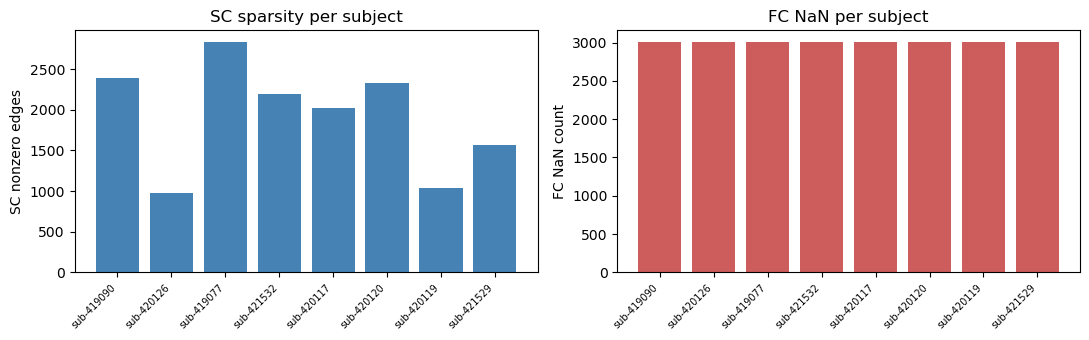

  saved: ./output_mouse_mptp/step1_subjects.png


In [3]:
df, fc_mat, sc_mat, fc_ids, sc_ids, bold_mat, bold_ids = (
    data_loader.load_raw_data()
)
subjects = data_loader.get_target_subjects(df, fc_ids, sc_ids)
train, val, test = data_loader.three_way_split(subjects)

subject_data = data_loader.load_all_subjects(
    train + val + test,
    fc_mat, sc_mat, fc_ids, sc_ids,
    bold_mat, bold_ids,
)

# Result
evaluate.report_step1(train, val, test, subject_data)


## Train data: weights / tract lengths / empirical FC

Step 1 직후 실행. Train subject 4명의 SC(weights), SC tract length, empirical FC를 로드하고 출력합니다.

  Train subjects (4): ['sub-419090', 'sub-420126', 'sub-419077', 'sub-421532']
  sub-419090:  SC=[0.1064, 1.0000]  length=[1.0, 15.6]mm  delay=[0.65, 10.38]ms  FC=[-0.658, 0.879]  SC_nnz=2388
  sub-420126:  SC=[0.1023, 1.0000]  length=[1.0, 10.8]mm  delay=[0.65, 7.20]ms  FC=[-0.770, 0.918]  SC_nnz=982
  sub-419077:  SC=[0.1008, 1.0000]  length=[1.0, 20.8]mm  delay=[0.65, 13.88]ms  FC=[-0.824, 0.936]  SC_nnz=2836
  sub-421532:  SC=[0.1107, 1.0000]  length=[1.0, 14.6]mm  delay=[0.65, 9.74]ms  FC=[-0.457, 0.885]  SC_nnz=2190


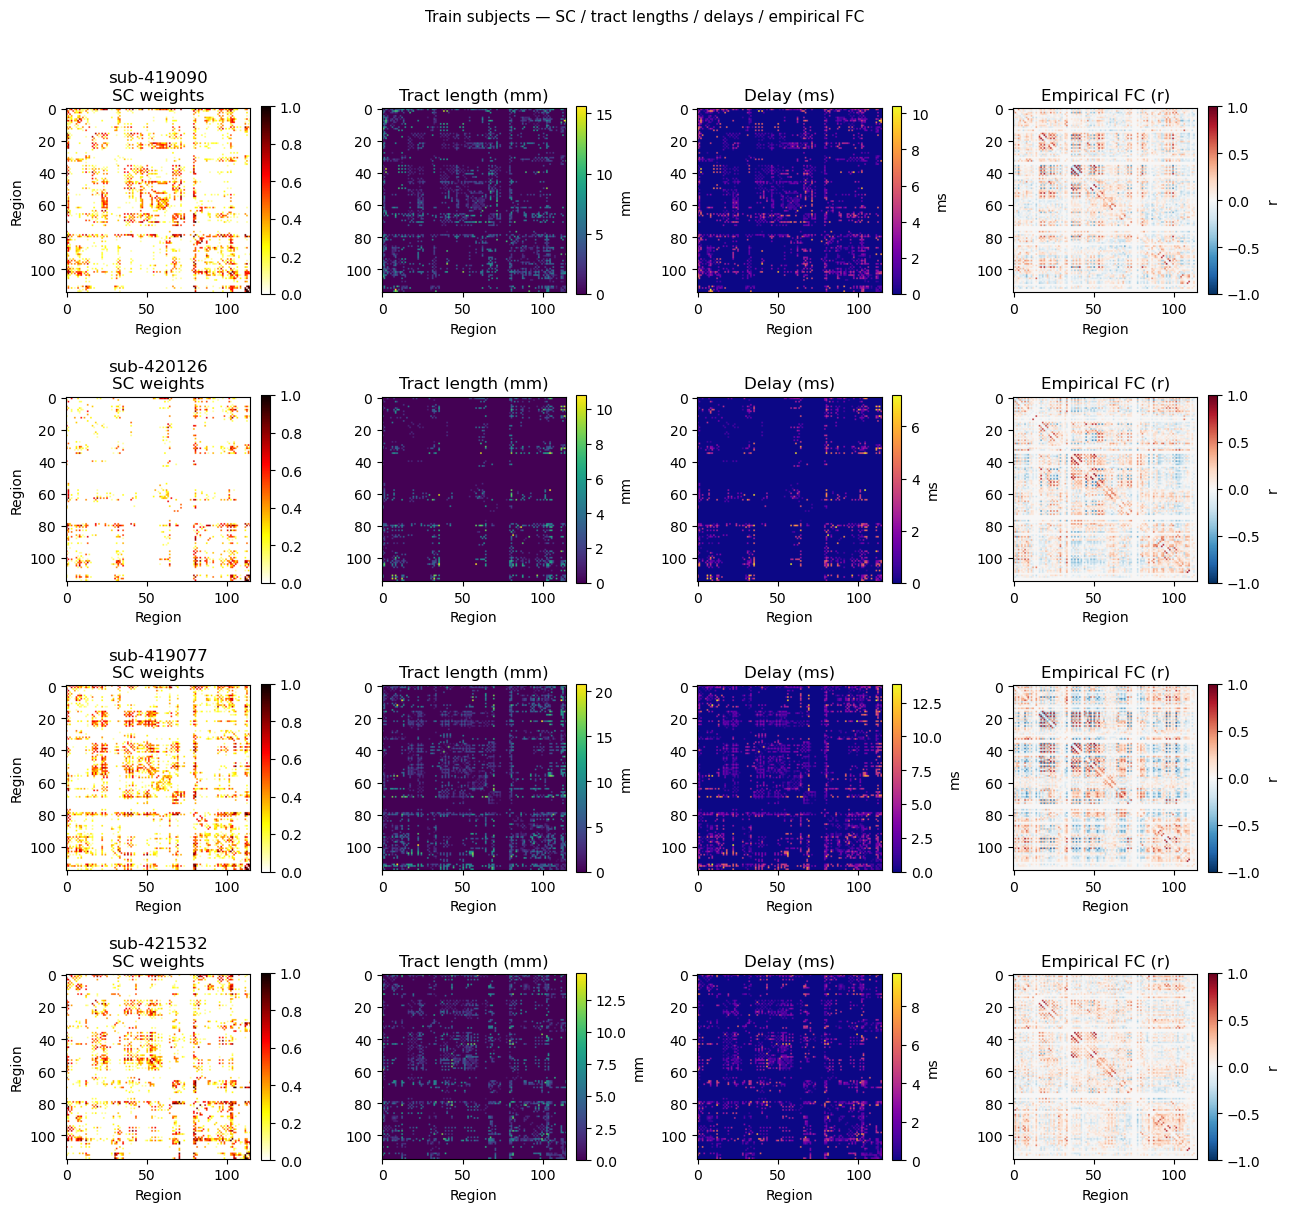

  saved: ./output_mouse_mptp/train_data_matrices.png


In [4]:
import numpy as np
import matplotlib.pyplot as plt

print("=" * 65)
print(f"  Train subjects ({len(train)}): {train}")
print("=" * 65)

# ── 1. 각 subject 데이터 출력 ────────────────────────────────
for sid in train:
    d   = subject_data[sid]
    w   = d["sc"].astype(np.float32)           # log1p + max-norm
    lm  = d["lengths_mm"].astype(np.float32)   # tract length (mm), col 2
    dl  = d["delays"].astype(np.float32)        # delay (ms)
    fc  = d["fc"].astype(np.float32)            # empirical FC

    w_pos  = w[w > 0]
    lm_pos = lm[lm > 0]
    dl_pos = dl[dl > 0]
    fc_off = fc[np.eye(fc.shape[0]) == 0]

    print(
        f"  {sid}:"
        f"  SC=[{w_pos.min():.4f}, {w_pos.max():.4f}]"
        f"  length=[{lm_pos.min():.1f}, {lm_pos.max():.1f}]mm"
        f"  delay=[{dl_pos.min():.2f}, {dl_pos.max():.2f}]ms"
        f"  FC=[{fc_off.min():.3f}, {fc_off.max():.3f}]"
        f"  SC_nnz={int((w > 0).sum())}"
    )

# ── 2. 시각화 ──────────────────────────────────────────────
n_train = len(train)
fig, axes = plt.subplots(n_train, 4,
                         figsize=(13, 3.0 * n_train),
                         squeeze=False)

for row, sid in enumerate(train):
    d  = subject_data[sid]
    w  = d["sc"].astype(np.float32)
    lm = d["lengths_mm"].astype(np.float32)
    dl = d["delays"].astype(np.float32)
    fc = d["fc"].astype(np.float32)

    # SC weights
    im0 = axes[row, 0].imshow(w, cmap="hot_r", vmin=0, vmax=1)
    axes[row, 0].set_title(f"{sid}\nSC weights")
    axes[row, 0].set_ylabel("Region")
    plt.colorbar(im0, ax=axes[row, 0], fraction=0.046)

    # Tract lengths (mm)
    im1 = axes[row, 1].imshow(lm, cmap="viridis")
    axes[row, 1].set_title("Tract length (mm)")
    plt.colorbar(im1, ax=axes[row, 1], fraction=0.046, label="mm")

    # Delays (ms)
    im2 = axes[row, 2].imshow(dl, cmap="plasma")
    axes[row, 2].set_title("Delay (ms)")
    plt.colorbar(im2, ax=axes[row, 2], fraction=0.046, label="ms")

    # Empirical FC
    im3 = axes[row, 3].imshow(fc, cmap="RdBu_r", vmin=-1, vmax=1)
    axes[row, 3].set_title("Empirical FC (r)")
    plt.colorbar(im3, ax=axes[row, 3], fraction=0.046, label="r")

for ax in axes.flat:
    ax.set_xlabel("Region")

plt.suptitle(
    "Train subjects — SC / tract lengths / delays / empirical FC",
    fontsize=11, y=1.01,
)
plt.tight_layout()
save_path = "./output_mouse_mptp/train_data_matrices.png"
plt.savefig(save_path, dpi=110, bbox_inches="tight")
plt.show()
print(f"  saved: {save_path}")


## Step 7. Parameter preprocessing ([-1, 1] scaling)

Step 7 runs before step 2 because the simulation needs `prior_scaled` to sample parameters.

In [5]:
param_scaler, prior_scaled = inference.step7_fit_param_scaler(
    verbose=True
)

# Result
evaluate.report_step7(param_scaler)



  [Step 7] Parameter scaling ([-1, 1])
    P      : [0.5, 2.5] -> [-1, 1]
    Q      : [0.0, 2.0] -> [-1, 1]
    g_e    : [0.0, 1.5] -> [-1, 1]
    g_i    : [0.0, 1.5] -> [-1, 1]

  Step 7 result
  Prior bounds:
    P      : [  0.500,   2.500]  -> [-1, 1]
    Q      : [  0.000,   2.000]  -> [-1, 1]
    g_e    : [  0.000,   1.500]  -> [-1, 1]
    g_i    : [  0.000,   1.500]  -> [-1, 1]


## Step 2. WC simulation

Feature extraction (step 3) is interleaved inside this loop.

  [13:26:48] [Step 2] WC simulation start  (n_sim=10000, GPU_BATCH=10000, subjects=4)
  Training data collection: 4 subjects x 10000 = 40000 sims
  [13:26:48] [1/4] sub-419090  (1 batches x 10000 sims)
  [13:28:04] batch 1/1  sim 10000/10000  total 0/40000 (0.0%)  (76.7s)
  [13:28:06] sub-419090 done: 10000 samples  (77.8s)
  [13:28:06] [2/4] sub-420126  (1 batches x 10000 sims)
  [13:29:22] batch 1/1  sim 10000/10000  total 10000/40000 (25.0%)  (76.0s)
  [13:29:23] sub-420126 done: 20000 samples  (77.0s)
  [13:29:23] [3/4] sub-419077  (1 batches x 10000 sims)
  [13:30:39] batch 1/1  sim 10000/10000  total 20000/40000 (50.0%)  (76.1s)
  [13:30:40] sub-419077 done: 30000 samples  (77.1s)
  [13:30:40] [4/4] sub-421532  (1 batches x 10000 sims)
  [13:31:56] batch 1/1  sim 10000/10000  total 30000/40000 (75.0%)  (76.3s)
  [13:31:57] sub-421532 done: 40000 samples  (77.3s)

  Total collected: theta=(40000, 4), fc=(40000, 6555), fcd=(40000, 5)  (309.7s)

  Step 2 result
  theta_scaled : (400

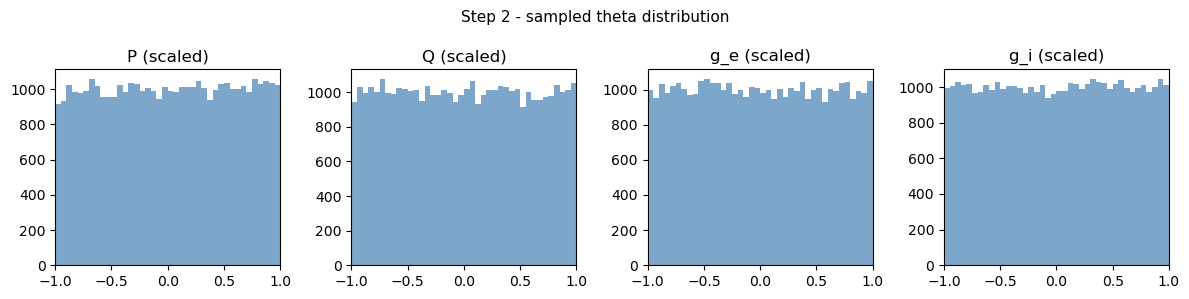

  saved: ./output_mouse_mptp/step2_theta_hist.png


In [6]:
import os

_feat_path = os.path.join(config.OUTPUT_DIR, "features_stage1.npz")

if os.path.exists(_feat_path):
    # 저장된 features 재사용 (Step 2 시뮬 skip)
    print(f"  [Step 2 skip] loading saved features: {_feat_path}")
    _loaded = inference.load_extracted_features(
        save_dir=config.OUTPUT_DIR, tag="stage1"
    )
    theta_scaled = _loaded["theta_scaled"]
    theta_raw    = _loaded["theta_raw"]
    fc_raw       = _loaded["fc_raw"]
    fcd_raw      = _loaded["fcd_raw"]
    print(f"  theta_scaled : {theta_scaled.shape}")
    print(f"  fc_raw       : {fc_raw.shape}")
    print(f"  fcd_raw      : {fcd_raw.shape}")

else:
    # 저장된 데이터 없으면 시뮬 실행
    theta_scaled, theta_raw, fc_raw, fcd_raw = inference.step2_simulate_train(
        train, subject_data, prior_scaled, param_scaler,
        n_sim=config.N_SIM, apply_bw=True, verbose=True,
    )

# Result
evaluate.report_step2(theta_scaled, fc_raw, fcd_raw)


### Step 2 진단: train subject 1명의 시뮬 결과 시각화

10000개 시뮬 중 하나를 다시 돌려서 BOLD 시계열과 simulated FC를 확인합니다.

  [one-sim plot] sid=sub-419090  sim_idx=0
    params = {'P': 2.264538526535034, 'Q': 1.8300079107284546, 'g_e': 0.5742956399917603, 'g_i': 1.4389584064483643}
    BOLD shape : (10, 115)
    BOLD range : [-0.369, 0.453]  std=0.128
    Sim FC vs Obs FC: Pearson r = -0.0054


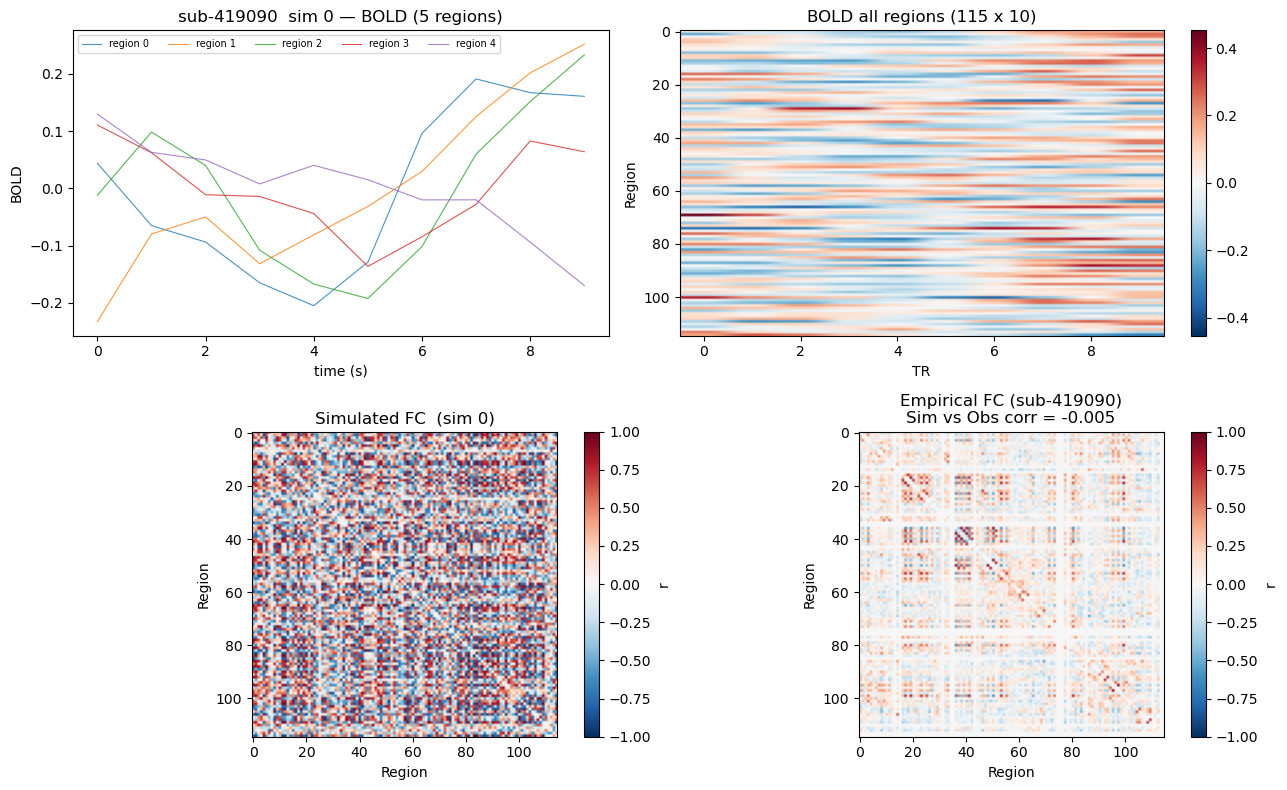

  saved: ./output_mouse_mptp/step2_one_sim.png


In [7]:
# Step 2 결과 진단: train의 첫 subject, 첫 시뮬 (idx=0) 시각화
_one_sim = evaluate.plot_one_simulation(
    sid=train[0],
    subject_data=subject_data,
    theta_raw=theta_raw,
    param_names=config.STAGE1_PARAMS,
    sim_idx=0,
)


## Step 3. Feature extraction summary

Step 2의 streaming loop 안에서 이미 추출된 feature를 정리하고, **raw feature를 디스크에 저장**합니다.

- `fc_raw` : FC upper triangle (Fisher z-transformed)
- `fcd_raw` : FCD upper triangle (element-wise std of sliding-window FCs)

저장 경로: `{OUTPUT_DIR}/features_stage1.npz`  
Load 방법: `inference.load_extracted_features(tag="stage1")`


  [Step 3] Feature summary
    FC  raw : (40000, 6555)  (finite=True)
    FCD raw : (40000, 5)  (finite=True)

  [save_features] ./output_mouse_mptp/features_stage1.npz  (926.3 MB)
    theta_scaled : (40000, 4)
    theta_raw    : (40000, 4)
    fc_raw       : (40000, 6555)  (Fisher-z upper tri)
    fcd_raw      : (40000, 5)  (FCD upper tri)

  Step 3 result
  FC  raw : shape=(40000, 6555), min=-0.999, max=1.000, mean=0.006
  FCD raw : shape=(40000, 5), min=0.000, max=0.000, mean=0.000


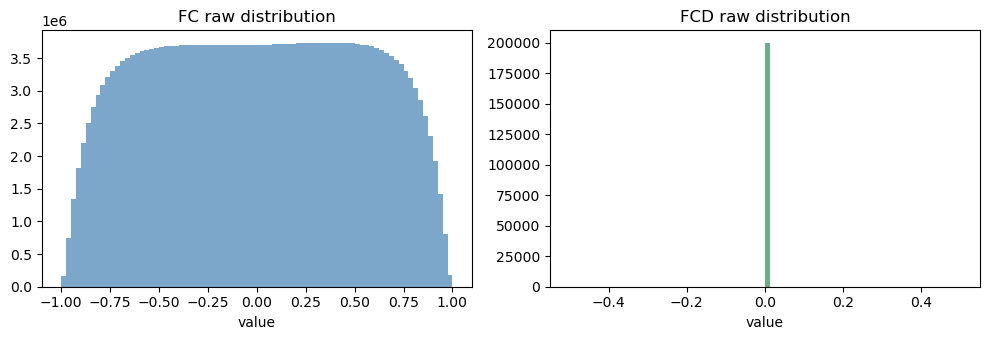

  saved: ./output_mouse_mptp/step3_feature_dist.png


In [8]:
inference.step3_summary_features(fc_raw, fcd_raw, verbose=True)

# Save raw features only if not already saved (Step 2 may have loaded them)
import os
_feat_path = os.path.join(config.OUTPUT_DIR, "features_stage1.npz")
if not os.path.exists(_feat_path):
    inference.save_extracted_features(
        theta_scaled, theta_raw, fc_raw, fcd_raw,
        param_names=config.STAGE1_PARAMS,
        save_dir=config.OUTPUT_DIR,
        tag="stage1",
        verbose=True,
    )
else:
    print(f"  features_stage1.npz exists — skip save")

# Result
evaluate.report_step3(fc_raw, fcd_raw)


## Step 4. Feature preprocessing (z-score, train only)

  [13:33:48] [Step 4] Fit feature z-score scalers (train only)
    FC  z: disabled (FC is Pearson r in [-1, 1])
    FCD z: disabled (USE_FCD=False)
  [13:33:48] [Step 4] done

  Step 4 result
  FC     : raw Pearson r [-1, 1], no z-score
  FCD    : disabled (USE_FCD=False)


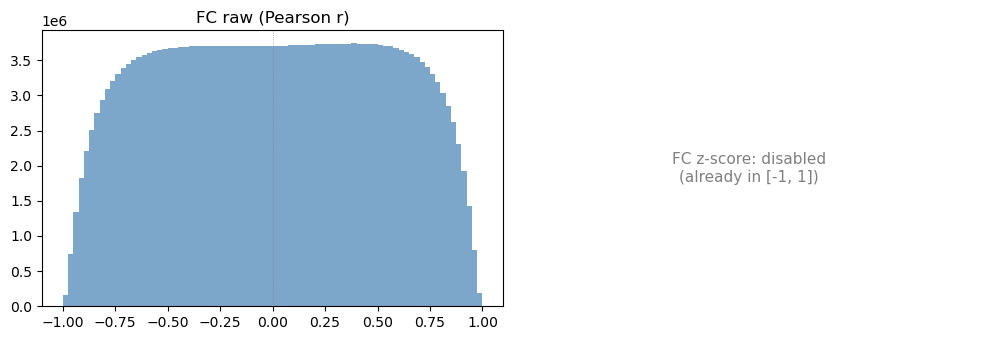

  saved: ./output_mouse_mptp/step4_zscore.png


In [9]:
scalers = inference.step4_fit_feature_scalers(
    fc_raw, fcd_raw, verbose=True
)

# Result
evaluate.report_step4(scalers, fc_raw, fcd_raw)


## Step 5. Feature embedding (FC PCA + FCD summary stats)

- FC (6555-dim) → z-score → PCA → `PCA_DIM_FC` (default 200)
- FCD (5-dim summary stats: mean, std, q25, q50, q75) → z-score only
- Concatenated input dim = `PCA_DIM_FC + 5`

In [ ]:
pipeline, x_input = inference.step5_fit_feature_pipeline(
    fc_raw, fcd_raw, verbose=True
)

# Result
evaluate.report_step5(pipeline, x_input)


  [13:33:51] [Step 5] Fit FC + FCD PCA pipeline  (FC: (40000, 6555) -> 200 PCs, FCD: (40000, 5) -> 100 PCs)


## Step 6. Embedding quality check (PCA diagnostic)

FC PCA의 explained variance, reconstruction quality, train/val drift를 확인합니다. FCD는 5-dim summary stats라 PCA 진단 없이 요약 정보만 출력합니다.

In [ ]:
pca_diagnostic = inference.step6_pca_diagnostic(
    pipeline, fc_raw, fcd_raw, verbose=True
)
evaluate.plot_pca_diagnostic(pca_diagnostic)

# Result
evaluate.report_step6(pca_diagnostic)


## Step 8. Stage 1 inference (single-round SNPE-C)

In [ ]:
posterior, embedding_net = inference.step8_train_snpe(
    theta_scaled, x_input, prior_scaled, verbose=True
)

s1 = {
    "posterior":        posterior,
    "embedding_net":    embedding_net,
    "theta_scaled":     theta_scaled,
    "theta_raw":        theta_raw,
    "fc_raw":           fc_raw,
    "fcd_raw":          fcd_raw,
    "x_input":          x_input,
    "param_scaler":     param_scaler,
    "feature_pipeline": pipeline,
    "prior_scaled":     prior_scaled,
    "pca_diagnostic":   pca_diagnostic,
}

# Result
evaluate.report_step8(posterior, embedding_net, theta_scaled, x_input)


## Step 9. Stage 1 analysis (validation)

9a validation metrics · 9b baseline · 9c MLP probing · 9d SBC · 9e posterior plots

In [ ]:
stage1_agg = evaluate.evaluate_validation_stage1(
    val, subject_data, s1, apply_bw=True, verbose=True,
)

baseline_agg = evaluate.baseline_eval_subjects(
    val, subject_data, n_resim=10, verbose=True,
)

inference.evaluate_embedding_probing(
    s1["embedding_net"], s1["theta_scaled"],
    s1["x_input"], config.STAGE1_PARAMS, verbose=True,
)

sbc_ranks = inference.simulation_based_calibration(
    s1["posterior"], s1["prior_scaled"], s1["param_scaler"],
    s1["feature_pipeline"], config.STAGE1_PARAMS,
    weights=subject_data[train[0]]["sc"],
    delays=subject_data[train[0]]["delays"],
    n_sbc=config.N_SBC, n_posterior=1000,
)
evaluate.plot_sbc_rank_histogram(sbc_ranks, config.STAGE1_PARAMS)
evaluate.plot_posteriors(
    stage1_agg["per_subject"],
    config.STAGE1_PARAMS,
    config.STAGE1_PRIOR_LOW,
    config.STAGE1_PRIOR_HIGH,
    title="Stage 1",
)

# Result
evaluate.report_step9(stage1_agg, baseline_agg)


## Step 10. Stage 2 parameter selection

In [ ]:
val_shrinkage = stage1_agg["shrinkage_mean"]
difficult = inference.select_difficult_params(val_shrinkage)

# Result
evaluate.report_step10(difficult, val_shrinkage)


## Step 11. Stage 2 inference

In [ ]:
import os

_feat_path_s2 = os.path.join(config.OUTPUT_DIR, "features_stage2.npz")

if os.path.exists(_feat_path_s2):
    # 저장된 Stage 2 features 재사용
    print(f"  [Step 11 skip] loading saved features: {_feat_path_s2}")
    _loaded_s2 = inference.load_extracted_features(
        save_dir=config.OUTPUT_DIR, tag="stage2"
    )
    # s2 dict 재구성 (stage2_params 포함)
    s2 = dict(s1)   # s1 기반으로 공통 키 복사
    s2["theta_scaled"]  = _loaded_s2["theta_scaled"]
    s2["theta_raw"]     = _loaded_s2["theta_raw"]
    s2["fc_raw"]        = _loaded_s2["fc_raw"]
    s2["fcd_raw"]       = _loaded_s2["fcd_raw"]
    s2["stage2_params"] = _loaded_s2["param_names"]
    print(f"  theta_scaled  : {s2['theta_scaled'].shape}")
    print(f"  fc_raw        : {s2['fc_raw'].shape}")
    print(f"  stage2_params : {s2['stage2_params']}")

else:
    # 저장된 데이터 없으면 시뮬 실행
    s2 = inference.run_stage2_snpe(
        train, subject_data, s1, val_shrinkage,
        n_sim=config.N_SIM_S2, apply_bw=True, verbose=True,
    )
    # Save Stage 2 raw extracted features
    inference.save_extracted_features(
        s2["theta_scaled"], s2["theta_raw"],
        s2["fc_raw"], s2["fcd_raw"],
        param_names=s2["stage2_params"],
        save_dir=config.OUTPUT_DIR,
        tag="stage2",
        verbose=True,
    )

# Result
evaluate.report_step11(s2)


## Step 12. Stage 2 analysis (validation)

In [ ]:
stage2_agg = evaluate.evaluate_validation_stage2(
    val, subject_data, s2, s1, apply_bw=True, verbose=True,
)
evaluate.plot_posteriors(
    stage2_agg["per_subject"],
    s2["stage2_params"],
    s2["param_scaler"].low.tolist(),
    s2["param_scaler"].high.tolist(),
    title="Stage 2",
)

# Result
evaluate.report_step12(stage2_agg)


## Step 13. Model selection (validation)

In [ ]:
best_stage, score_1, score_2 = evaluate.select_best_model(
    stage1_agg, stage2_agg, baseline_agg, verbose=True,
)

# Result
evaluate.report_step13(best_stage, score_1, score_2, stage1_agg, stage2_agg)


## Step 14. Final test

In [ ]:
test_summary = evaluate.final_test(
    test, subject_data, best_stage, s1, s2,
    n_resim=config.N_TEST_RESIM, apply_bw=True, verbose=True,
)
evaluate.plot_fc_comparison(
    test_summary["per_subject"],
    save_path=os.path.join(config.OUTPUT_DIR, "test_fc_comparison.png"),
    title=f"Test FC (Stage {best_stage})",
)

# Result
evaluate.report_step14(test_summary)


## Save outputs and summary

In [ ]:
inference.save_artifacts(
    os.path.join(config.OUTPUT_DIR, "artifacts.pkl"),
    stage1_param_scaler     = s1["param_scaler"].to_dict(),
    stage1_feature_pipeline = s1["feature_pipeline"],
    stage1_pca_diagnostic   = s1["pca_diagnostic"],
    stage2_param_scaler     = s2["param_scaler"].to_dict() if s2 else None,
    stage2_feature_pipeline = s2["feature_pipeline"] if s2 else None,
    stage2_params           = s2["stage2_params"] if s2 else None,
    nuisance_params         = s2["nuisance_params"] if s2 else None,
    best_stage              = best_stage,
    n_regions               = config.N_REGIONS,
    fc_dim                  = config.FC_DIM,
    prior_low               = config.STAGE1_PRIOR_LOW,
    prior_high              = config.STAGE1_PRIOR_HIGH,
    param_names_s1          = config.STAGE1_PARAMS,
    c_param_prior           = config.C_PARAM_PRIOR,
    feature_config          = {
        "pca_dim_fc":  s1["feature_pipeline"].fc_pca.n_components,
        "pca_dim_fcd": s1["feature_pipeline"].fcd_pca.n_components,
    },
)

torch.save(
    s1["embedding_net"].state_dict(),
    os.path.join(config.OUTPUT_DIR, "embedding_net_s1.pt"),
)
if s2 is not None:
    torch.save(
        s2["embedding_net"].state_dict(),
        os.path.join(config.OUTPUT_DIR, "embedding_net_s2.pt"),
    )

evaluate.print_final_summary(
    stage1_agg, stage2_agg, best_stage, test_summary,
    train, len(s1["theta_scaled"]),
)
